# Kelompok 3

## Klasifikasi Tingkat Obesitas  
### Menggunakan Algoritma Decision Tree dan Naive Bayes

**Anggota Kelompok:**
1. Fakhri Faturohman (1512623049)
2. Muhammad Farid (1512623016)
3. Virgiawan Listiyanto (1512623002)


# 1. Import Library


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, KFold, cross_val_predict
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import accuracy_score, precision_score, recall_score


# 2. Load Data

In [4]:
# path file raw dataset
pathFile = "https://raw.githubusercontent.com/faridd35/klasifikasi-tingkat-obesitas-machine-learning/refs/heads/main/ObesityDataSet_raw_and_data_sinthetic.csv"

# load dataset
df = pd.read_csv(pathFile)
df.head()

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


# 3. Deskripsi Dataset

In [5]:
df['NObeyesdad'].value_counts()

,count
NObeyesdad,
Obesity_Type_I,351
Obesity_Type_III,324
Obesity_Type_II,297
Overweight_Level_I,290
Overweight_Level_II,290
Normal_Weight,287
Insufficient_Weight,272


In [6]:
# informasi dataset
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Gender                          2111 non-null   object 
 1   Age                             2111 non-null   float64
 2   Height                          2111 non-null   float64
 3   Weight                          2111 non-null   float64
 4   family_history_with_overweight  2111 non-null   object 
 5   FAVC                            2111 non-null   object 
 6   FCVC                            2111 non-null   float64
 7   NCP                             2111 non-null   float64
 8   CAEC                            2111 non-null   object 
 9   SMOKE                           2111 non-null   object 
 10  CH2O                            2111 non-null   float64
 11  SCC                             2111 non-null   object 
 12  FAF                             21

In [7]:
# cek missing value
df.isnull().sum()


,0
Gender,0
Age,0
Height,0
Weight,0
family_history_with_overweight,0
FAVC,0
FCVC,0
NCP,0
CAEC,0
SMOKE,0


# 4. Pemisahan Fitur dan Label

In [8]:
X = df.drop("NObeyesdad", axis=1)
y = df["NObeyesdad"]


# 5. Preprocessing Data

In [9]:
# encoding data kategorikal
for col in X.select_dtypes(include="object").columns:
    X[col] = LabelEncoder().fit_transform(X[col])

# scaling data numerik
num_cols = X.select_dtypes(include=["int64", "float64"]).columns
X[num_cols] = StandardScaler().fit_transform(X[num_cols])


# 6. Inisialisasi Model

In [10]:
decision_tree = DecisionTreeClassifier(random_state=42)
naive_bayes = GaussianNB()


# 7. Evaluasi dan Pengujian Model


In [11]:
def evaluate(y_asli, y_pred):
    acc = accuracy_score(y_asli, y_pred)
    prec = precision_score(y_asli, y_pred, average="weighted")
    rec = recall_score(y_asli, y_pred, average="weighted")
    return acc, prec, rec


In [13]:
hasil = []

In [14]:
# Holdout data latih = 80 data uji = 20
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

decision_tree.fit(X_train, y_train)
naive_bayes.fit(X_train, y_train)

hasil.append(["Holdout 80:20", "Decision Tree",
              *evaluate(y_test, decision_tree.predict(X_test))])
hasil.append(["Holdout 80:20", "Naive Bayes",
              *evaluate(y_test, naive_bayes.predict(X_test))])


In [15]:
# Holdout data latih = 70 data uji = 30
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

decision_tree.fit(X_train, y_train)
naive_bayes.fit(X_train, y_train)

hasil.append(["Holdout 70:30", "Decision Tree",
              *evaluate(y_test, decision_tree.predict(X_test))])
hasil.append(["Holdout 70:30", "Naive Bayes",
              *evaluate(y_test, naive_bayes.predict(X_test))])


In [16]:
# K-Fold (k = 5)
kf5 = KFold(n_splits=5, shuffle=True, random_state=42)

hasil.append(["K-Fold (5)", "Decision Tree",
              *evaluate(y, cross_val_predict(decision_tree, X, y, cv=kf5))])
hasil.append(["K-Fold (5)", "Naive Bayes",
              *evaluate(y, cross_val_predict(naive_bayes, X, y, cv=kf5))])


In [17]:
# K-Fold (k = 10)
kf10 = KFold(n_splits=10, shuffle=True, random_state=42)

hasil.append(["K-Fold (10)", "Decision Tree",
              *evaluate(y, cross_val_predict(decision_tree, X, y, cv=kf10))])
hasil.append(["K-Fold (10)", "Naive Bayes",
              *evaluate(y, cross_val_predict(naive_bayes, X, y, cv=kf10))])


# 8. Tabel hasil perbandingan

In [18]:
df_hasil = pd.DataFrame(
    hasil,
    columns=["Skema", "Algoritma", "Akurasi", "Presisi", "Recall"]
).round(3)

df_hasil


,Skema,Algoritma,Akurasi,Presisi,Recall
0,Holdout 80:20,Decision Tree,0.917,0.921,0.917
1,Holdout 80:20,Naive Bayes,0.598,0.649,0.598
2,Holdout 70:30,Decision Tree,0.913,0.915,0.913
3,Holdout 70:30,Naive Bayes,0.588,0.614,0.588
4,K-Fold (5),Decision Tree,0.932,0.932,0.932
5,K-Fold (5),Naive Bayes,0.595,0.614,0.595
6,K-Fold (10),Decision Tree,0.942,0.942,0.942
7,K-Fold (10),Naive Bayes,0.604,0.623,0.604


# 9. Grafik Perbandingan

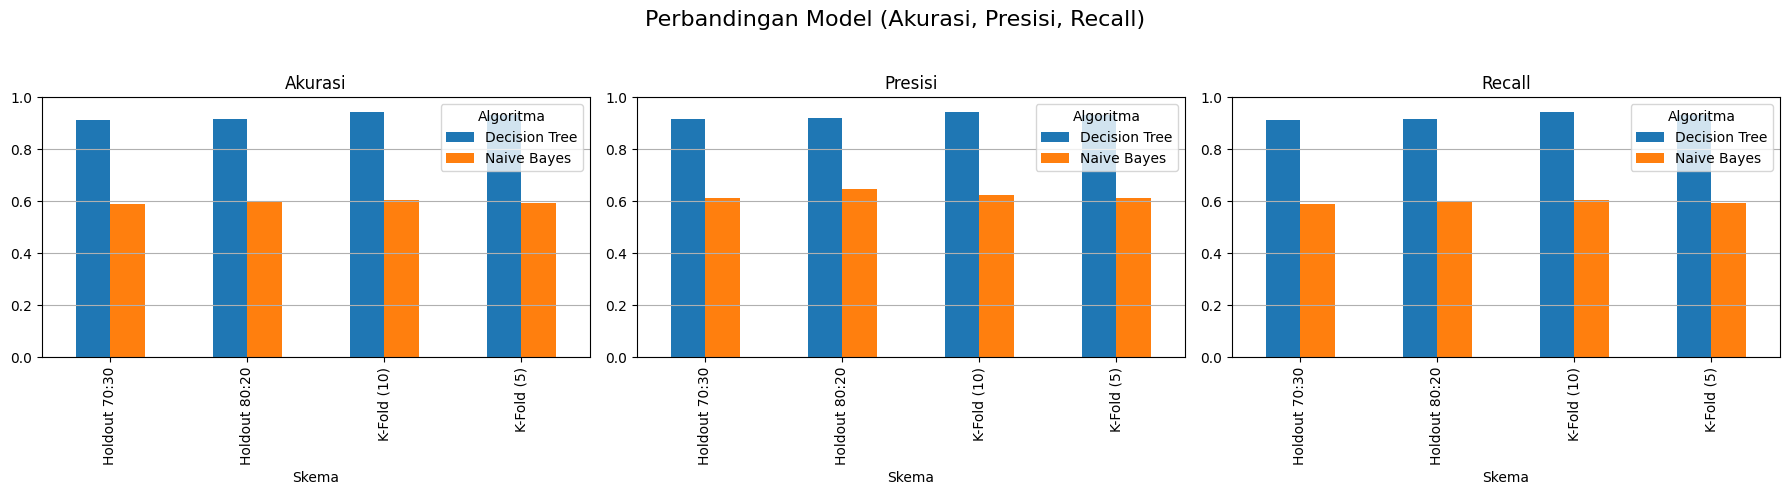

In [19]:
#Visualisasi pivot
pivot_akurasi = df_hasil.pivot(index="Skema", columns="Algoritma", values="Akurasi")
pivot_presisi = df_hasil.pivot(index="Skema", columns="Algoritma", values="Presisi")
pivot_recall = df_hasil.pivot(index="Skema", columns="Algoritma", values="Recall")

#Membuat 3 subplot
fig, axes = plt.subplots(1, 3, figsize=(18,5))  # 1 baris, 3 kolom

#Plot Akurasi
pivot_akurasi.plot(kind="bar", ax=axes[0])
axes[0].set_title("Akurasi")
axes[0].set_ylim(0,1)
axes[0].grid(axis="y")

#Plot Presisi
pivot_presisi.plot(kind="bar", ax=axes[1])
axes[1].set_title("Presisi")
axes[1].set_ylim(0,1)
axes[1].grid(axis="y")

#Plot Recall
pivot_recall.plot(kind="bar", ax=axes[2])
axes[2].set_title("Recall")
axes[2].set_ylim(0,1)
axes[2].grid(axis="y")

plt.suptitle("Perbandingan Model (Akurasi, Presisi, Recall)", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()
